<a href="https://colab.research.google.com/github/walter-04/TFM_Canine/blob/feature%2FVibe_codec/unific_size_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from nibabel.affines import rescale_affine, voxel_sizes
from nibabel.processing import resample_from_to
from scipy.ndimage import affine_transform
from skimage.segmentation import slic, mark_boundaries
from skimage.exposure import match_histograms
from skimage.segmentation import felzenszwalb
from skimage.transform import SimilarityTransform, warp
from skimage.filters import threshold_otsu
from skimage.morphology import disk, dilation
import skimage
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as pltImage
import math
import scipy
import glob
import cv2

In [14]:
from google.colab import drive
drive.mount('/content/drive')
path_drive_data = "/content/drive/MyDrive/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
class Formate_nii:

  def __init__(self, init_nii):
    '''
    params:
      init_nii: ruta de la imagen a procesar
    '''
    self.cort_z = 250
    self.img_base_nii = nib.load(init_nii)

  def resample_nii(self, img_nii):
    '''
    params:
      img_nii: imagen a procesar
    return:
      img_nii_resize: imagen procesada
    '''
    new_matrix_affine = rescale_affine(img_nii.affine,
                                shape=img_nii.shape,
                                zooms=voxel_sizes(self.img_base_nii.affine),
                                new_shape=self.img_base_nii.shape)

    img_nii_resize = resample_from_to(img_nii,
                                (self.img_base_nii.shape, new_matrix_affine),
                                order=1, mode='nearest')
    return img_nii_resize

  def run(self, path_data):
    '''
    params:
      path_data: ruta de la carpeta con las imagenes a procesar
    '''
    files_nii = glob.glob(path_data)
    for file in files_nii:
      if "sub-17" not in file:
        img_nii = nib.load(file)
        name_file_nii = file.split('/')[-1]
        img_nii_resize = self.resample_nii(img_nii)
        print("Tratando:", file)
        print(" * Resample:",img_nii.shape," a ", img_nii_resize.shape)
        nib.save(img_nii_resize, path_drive_data+'data_nii_resize/'+name_file_nii)
        #img_nii_resize.to_filename(file)

Ejecución del proceso de redimencionamiento de los ficheros al valor (250, 288, 288)

In [30]:
formate = Formate_nii("/content/drive/MyDrive/data_nii/sub-17_T1w.nii")
formate.run("/content/drive/MyDrive/data_nii/*")

Tratando: /content/drive/MyDrive/data_nii/sub-21_T1w.nii
 * Resample: (250, 336, 336)  a  (250, 288, 288)
Tratando: /content/drive/MyDrive/data_nii/sub-23_T1w.nii
 * Resample: (250, 336, 336)  a  (250, 288, 288)
Tratando: /content/drive/MyDrive/data_nii/sub-24_T1w.nii
 * Resample: (250, 336, 336)  a  (250, 288, 288)
Tratando: /content/drive/MyDrive/data_nii/sub-25_T1w.nii
 * Resample: (267, 448, 448)  a  (250, 288, 288)
Tratando: /content/drive/MyDrive/data_nii/sub-26_T1w.nii
 * Resample: (220, 400, 400)  a  (250, 288, 288)
Tratando: /content/drive/MyDrive/data_nii/sub-27_T1w.nii
 * Resample: (220, 336, 336)  a  (250, 288, 288)
Tratando: /content/drive/MyDrive/data_nii/sub-28_T1w.nii
 * Resample: (250, 336, 336)  a  (250, 288, 288)
Tratando: /content/drive/MyDrive/data_nii/sub-22_T1w.nii
 * Resample: (250, 336, 336)  a  (250, 288, 288)
Tratando: /content/drive/MyDrive/data_nii/sub-31_T1w.nii
 * Resample: (250, 336, 336)  a  (250, 288, 288)
Tratando: /content/drive/MyDrive/data_nii/sub-

In [37]:
image_pe = nib.load("/content/drive/MyDrive/data_nii/sub-17_T1w.nii")
image_pe_2 = nib.load("/content/drive/MyDrive/data_nii/sub-34_T1w.nii")
img_grand = nib.load("/content/drive/MyDrive/data_nii_resize/sub-34_T1w.nii")

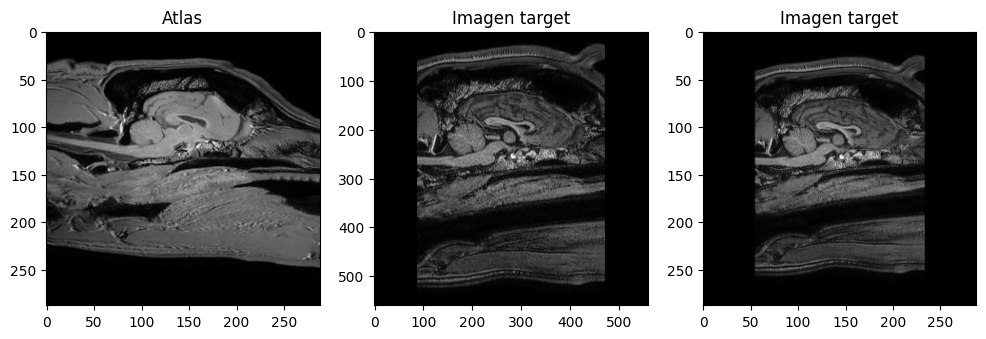

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
ax = axes.ravel()
ax[0].set_title('Atlas')
ax[0].imshow(image_pe.get_fdata()[125,:,:], cmap='Greys_r')
ax[1].set_title('Imagen target')
ax[1].imshow(image_pe_2.get_fdata()[200,:,:], cmap='Greys_r')
ax[2].set_title('Imagen target')
ax[2].imshow(img_grand.get_fdata()[125,:,:], cmap='Greys_r')

In [26]:
atlas_resize.shape

(250, 560, 560)

In [15]:
[[x,list_info.count(x)] for x in set(list_info)]

[[267, 2],
 [300, 2],
 [268, 1],
 [333, 1],
 [400, 1],
 [280, 1],
 [250, 27],
 [220, 2]]

(array([ 8., 14.,  5.,  1.,  3.,  1.,  2.,  2.,  0.,  1.]),
 array([288. , 323.2, 358.4, 393.6, 428.8, 464. , 499.2, 534.4, 569.6,
        604.8, 640. ]),
 <BarContainer object of 10 artists>)

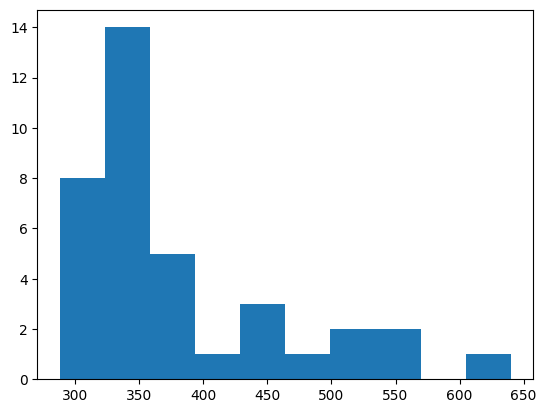

In [5]:
plt.hist(list_info)